# **A2.2 LDA y Árboles de Decisión**

---

### **Introducción**

En esta actividad se explorarán dos metodologías distintas para resolver un problema de clasificación: **Linear Discriminant Analysis (LDA)** y **Árboles de Decisión**. Ambos enfoques parten de supuestos y estructuras diferentes.

LDA construye fronteras de decisión lineales basándose en supuestos probabilísticos sobre la distribución de las clases (normalidad multivariada y matrices de covarianza homogéneas). Mientars que, los árboles de decisión generan particiones jerárquicas y rectangulares del espacio de variables sin asumir ninguna distribución específica ni linealidad.

El objetivo de este trabajo es aplicar ambos modelos al problema de clasificar estados de México por su nivel de incidencia delictiva (bajo, medio, alto) utilizando indicadores socioeconómicos de marginación. A través del análisis se espera:

- Entender cómo cada metodología interpreta la relación entre factores socioeconómicos y criminalidad
- Evaluar el desempeño de ambos modelos mediante métricas cuantitativas
- Reflexionar sobre cuál enfoque es más apropiado para este problema específico
- Interpretar los resultados desde perspectivas geométricas, estadísticas y prácticas

### **Carga de datos**

Este análisis utiliza un conjunto de datos integrado que combina información de incidencia delictiva nacional con indicadores socioeconómicos de marginación. El archivo ha sido descargado de un repositorio de GitHub (dataset preparado por Rodrigo Lopez) e integra datos de dos fuentes principales:

**Fuentes originales:**
- Datos de criminalidad del Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNSP): 2015-2023
- Indicadores de marginación del Consejo Nacional de Población (CONAPO): 2015 y 2020 (interpolados para años intermedios)

**Alcance del dataset:**
- 288 registros de estado-año (32 estados × 9 años)
- 10 variables predictoras: indicadores de marginación (analfabetismo, servicios básicos, hacinamiento, vivienda, pobreza extrema, etc.)
- 1 variable respuesta: tasa delictiva (delitos por 100,000 habitantes anualizados)

In [28]:
# ========================================
# IMPORTACIONES Y CONFIGURACIÓN INICIALES
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, auc, roc_auc_score, classification_report
)
import warnings
import unicodedata

warnings.filterwarnings('ignore')

# Configurar estilo de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Cargar dataset integrado
df_final = pd.read_csv('datos_clasificacion_limpios.csv')

print("Dataset cargado exitosamente")
print(f"  Dimensiones: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"  Período: {df_final['Año'].min()}-{df_final['Año'].max()}")
print(f"  Estados: {df_final['Entidad'].nunique()}")

print("\nPrimeras filas:")
display(df_final.head())

print("\nVariables del dataset:")
print(df_final.columns.tolist())

print("\nEstadísticas descriptivas:")
display(df_final.describe())

Dataset cargado exitosamente
  Dimensiones: 288 filas × 14 columnas
  Período: 2015-2023
  Estados: 32

Primeras filas:


,Entidad,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
0,AGUASCALIENTES,2015,1312544.0,17.883964,2.601353,29.721797,0.681147,0.304155,0.813920,0.752952,21.862232,25.162585,34.604084,1770.454933
1,BAJA CALIFORNIA,2015,3315766.0,18.464138,1.961601,30.077841,0.268934,0.472493,2.817705,1.148904,23.032223,10.349162,22.845516,3653.032210
2,BAJA CALIFORNIA SUR,2015,712029.0,17.320595,2.505451,29.439127,0.386485,1.136240,7.146918,4.083650,26.230970,15.618886,22.365039,3015.326623
3,CAMPECHE,2015,899931.0,13.684555,6.681547,35.743791,4.085619,1.589287,6.489314,2.949209,37.931783,30.875478,40.693940,221.572543
4,CHIAPAS,2015,5217908.0,8.449801,14.984097,53.400565,2.941142,2.485504,13.445785,11.775397,44.460574,57.856520,62.463392,419.190986



Variables del dataset:
['Entidad', 'Año', 'POB_TOT', 'IM', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM', 'Tasa_Delictiva']

Estadísticas descriptivas:


,Año,POB_TOT,IM,ANALF,SBASC,OVSDE,OVSEE,OVSAE,OVPT,VHAC,PL_5000,PO2SM,Tasa_Delictiva
count,288.000000,2.880000e+02,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,2019.000000,3.866561e+06,17.857534,4.973352,31.691383,1.978084,0.873265,4.021914,3.749695,23.043002,29.197001,57.133743,1511.028807
std,2.586483,3.197568e+06,3.303586,3.265801,7.732709,2.172880,0.675547,3.483437,3.566110,6.881851,16.184372,14.955664,840.120233
min,2015.000000,7.112350e+05,6.928344,1.429621,17.641964,0.051952,0.051820,0.552683,0.633649,13.132191,1.007987,16.147650,90.697652
25%,2017.000000,1.813176e+06,16.311494,2.643087,26.991249,0.567858,0.381912,1.403170,1.557448,17.505891,14.385886,46.791801,830.615409
50%,2019.000000,2.997990e+06,18.229581,3.899466,30.063351,1.411048,0.639300,2.820633,2.435722,22.235327,30.046267,58.504352,1457.950489
75%,2021.000000,4.841510e+06,20.083050,6.301040,34.826597,2.469859,1.160223,5.393310,4.303201,26.642784,39.074320,69.255061,2061.626970
max,2023.000000,1.699242e+07,23.444318,14.984097,53.400565,13.216815,2.874475,15.641990,15.266973,44.460574,61.508475,85.570274,3943.171300


### **Definición del problema de clasificación**

Para crear un problema de clasificación práctico y útil, se define la variable objetivo a partir de la tasa delictiva. En lugar de intentar predecir el número exacto de delitos (tarea mucho más compleja), se clasificarán los estados en tres niveles según terciles de la distribución:

- Bajo: Estados en el tercil inferior de incidencia delictiva (menor criminalidad)
- Medio: Estados en el tercil intermedio
- Alto: Estados en el tercil superior (mayor criminalidad)

Esta categorización es valiosa porque:
- Es más sencillo predecir categorías que valores continuos
- Refleja mejor las decisiones de política pública (¿qué nivel de intervención es necesario?)
- Distribuye equilibradamente los casos entre las tres clases

Los modelos LDA y Árboles de Decisión utilizarán los 10 indicadores de marginación para predecir cuál de estas tres clases corresponde a cada estado-año. Esto permite responder: ¿Qué indicadores socioeconómicos están más asociados con altos niveles de criminalidad?

Tasa Delictiva - Terciles:
  Bajo  ≤ 1018.23
  Medio: 1018.23 - 1862.05
  Alto  > 1862.05

Distribución de clases:
  Bajo:  95 ( 33.0%)
  Medio:  98 ( 34.0%)
  Alto:  95 ( 33.0%)


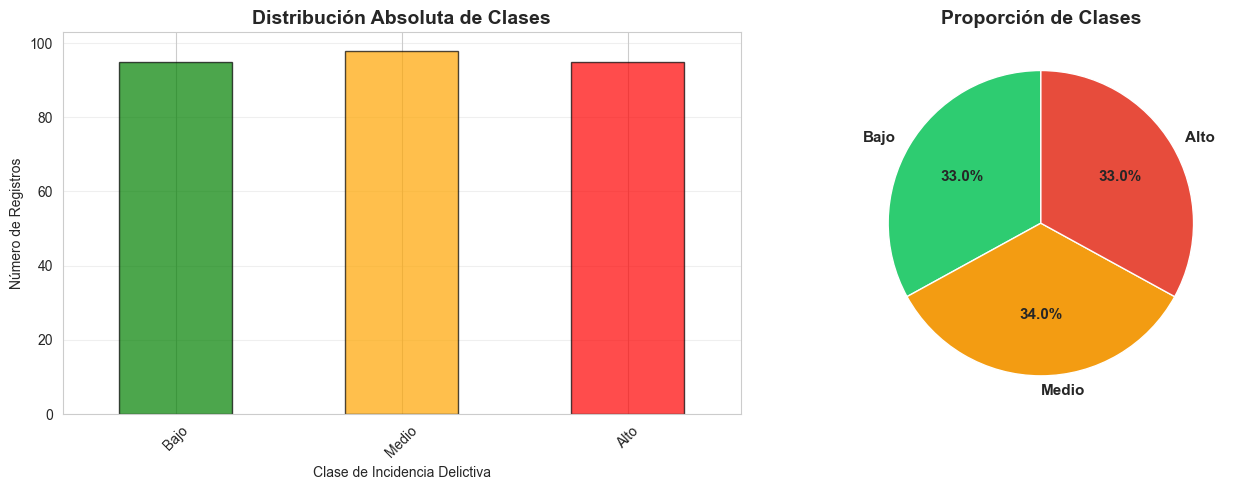


✓ Las clases están aproximadamente balanceadas (~33% cada una)
  Esto es importante para evaluaciones justas del modelo.


In [29]:
# Crear variable de clasificación basada en terciles de tasa delictiva
terciles = df_final['Tasa_Delictiva'].quantile([0.33, 0.67]).values
df_final['Clase_Delictiva'] = pd.cut(df_final['Tasa_Delictiva'], 
                                       bins=[-np.inf, terciles[0], terciles[1], np.inf],
                                       labels=['Bajo', 'Medio', 'Alto'])

print(f"Tasa Delictiva - Terciles:")
print(f"  Bajo  ≤ {terciles[0]:.2f}")
print(f"  Medio: {terciles[0]:.2f} - {terciles[1]:.2f}")
print(f"  Alto  > {terciles[1]:.2f}\n")

class_counts = df_final['Clase_Delictiva'].value_counts().sort_index()
print("Distribución de clases:")
for clase, count in class_counts.items():
    pct = (count / len(df_final)) * 100
    print(f"  {clase}: {count:3d} ({pct:5.1f}%)")

# =============================
# VISUALIZACIÓN DEL BALANCE DE CLASES
# =============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
class_counts.plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase de Incidencia Delictiva')
axes[0].set_ylabel('Número de Registros')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pastel
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Las clases están aproximadamente balanceadas (~33% cada una)")
print("  Esto es importante para evaluaciones justas del modelo.")

### **Interpretación del balance de clases**

Los resultados muestran que las tres clases están balanceadas (~33% cada una). Esto es crucial para los modelos de clasificación porque:

1. Evaluación justa: Un balance perfecto evita que el modelo simplemente aprenda a predecir siempre la clase más frecuente. Si hubiera un desbalance severo, el modelo podría lograr buena precisión simplemente prediciendo la clase mayoritaria  

2. Representación equitativa: Cada nivel de incidencia delictiva está representado de manera similar en los datos, lo que permite que los modelos aprendan patrones significativos de cada clase

3. Métricas confiables: Accuracy, Precision, Recall y F1-Score tendrán interpretaciones más claras cuando las clases están balanceadas

### **Partición Estratificada de datos**

Los datos se dividirán en dos conjuntos:
- 70% Entrenamiento (201 observaciones): El modelo aprenderá patrones de esta muestra
- 30% Prueba (87 observaciones): Evaluaremos el desempeño en datos nuevos que el modelo nunca ha visto

La estratificación asegura que ambos conjuntos mantengan la distribución 33-33-33 de las clases. Esto es superior a una partición aleatoria simple, que podría resultar en desbalances accidentales (por ejemplo, 40% Bajo, 35% Medio, 25% Alto).

In [30]:
# Seleccionar features (variables independientes)
features = ['IM', 'ANALF', 'SBASC', 'OVSDE', 'OVSEE', 'OVSAE', 'OVPT', 'VHAC', 'PL_5000', 'PO2SM']
X = df_final[features].copy()
y = df_final['Clase_Delictiva'].copy()

# Verificar valores faltantes
print(f"Valores faltantes en X:\n{X.isnull().sum()}\n")

# Imputar si hay faltantes
X = X.fillna(X.mean())

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

# Partición estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros\n")

# Verificar balance en ambos conjuntos
print("Balance en ENTRENAMIENTO:")
for clase in ['Bajo', 'Medio', 'Alto']:
    count = (y_train ==  clase).sum()
    pct = count / len(y_train) * 100
    print(f"  {clase}: {count} ({pct:.1f}%)")

print("\nBalance en PRUEBA:")
for clase in ['Bajo', 'Medio', 'Alto']:
    count = (y_test == clase).sum()
    pct = count / len(y_test) * 100
    print(f"  {clase}: {count} ({pct:.1f}%)")

# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print(f"\nFeatures normalizados (StandardScaler)")
print(f"  Media: {X_train_scaled.mean().mean():.6f}")
print(f"  Desv. Est.: {X_train_scaled.std().mean():.6f}")

Valores faltantes en X:
IM         0
ANALF      0
SBASC      0
OVSDE      0
OVSEE      0
OVSAE      0
OVPT       0
VHAC       0
PL_5000    0
PO2SM      0
dtype: int64

Features: (288, 10)
Target: (288,)
Entrenamiento: 201 registros
Prueba: 87 registros

Balance en ENTRENAMIENTO:
  Bajo: 66 (32.8%)
  Medio: 69 (34.3%)
  Alto: 66 (32.8%)

Balance en PRUEBA:
  Bajo: 29 (33.3%)
  Medio: 29 (33.3%)
  Alto: 29 (33.3%)

Features normalizados (StandardScaler)
  Media: 0.000000
  Desv. Est.: 1.002497


## 4. Modelo basado en Linear Discriminant Analysis (LDA)

### Supuestos de LDA

Linear Discriminant Analysis asume:

1. Distribución normal: Las características dentro de cada clase siguen una distribución normal multivariada
2. Homogeneidad de varianza: Las matrices de covarianza son iguales para todas las clases
3. Linealidad: Las fronteras de decisión entre clases son lineales
4. Independencia: Las observaciones son independientes entre sí

LDA busca encontrar combinaciones lineales de las variables originales que maximicen la separación entre clases, minimizando la variabilidad dentro de cada clase.

### Construcción del Modelo

Se entrena un modelo LDA con los datos normalizados. LDA reduce automáticamente el número de dimensiones a `k-1` funciones discriminantes donde k es 3, el número de clases.

Modelo LDA entrenado
Explicación de varianza:
  FD1: 87.5%
  FD2: 12.5%


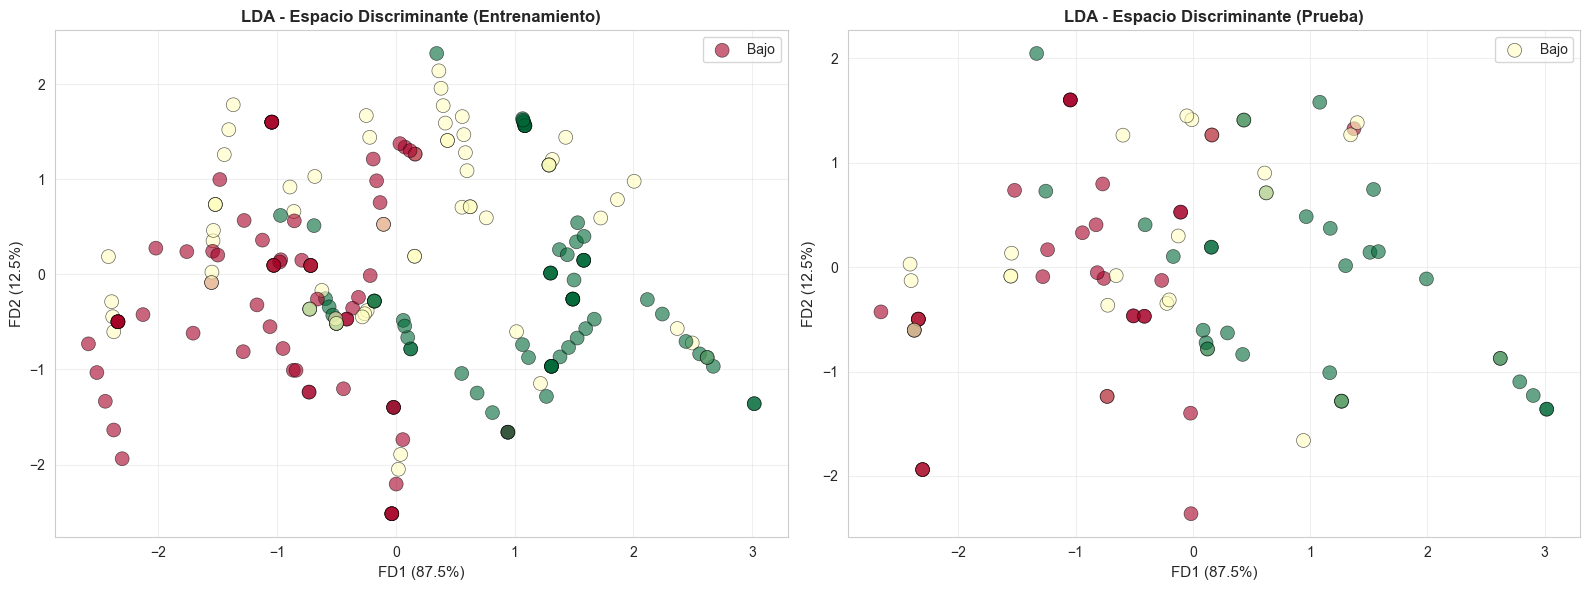

In [31]:
# Entrenar modelo LDA
lda_model = LinearDiscriminantAnalysis(n_components=2)
lda_model.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred_lda = lda_model.predict(X_train_scaled)
y_test_pred_lda = lda_model.predict(X_test_scaled)
y_pred_proba_lda = lda_model.predict_proba(X_test_scaled)

# Transformar a espacio discriminante
X_train_lda = lda_model.transform(X_train_scaled)
X_test_lda = lda_model.transform(X_test_scaled)

print(f"Modelo LDA entrenado")
print(f"Explicación de varianza:")
for i, var in enumerate(lda_model.explained_variance_ratio_):
    print(f"  FD{i+1}: {var*100:.1f}%")

# Visualizar espacio discriminante
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter_train = axes[0].scatter(X_train_lda[:, 0], X_train_lda[:, 1], 
                                c=y_train.map({'Bajo': 0, 'Medio': 1, 'Alto': 2}),
                                cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'FD1 ({lda_model.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'FD2 ({lda_model.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('LDA - Espacio Discriminante (Entrenamiento)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(*scatter_train.legend_elements(), labels=['Bajo', 'Medio', 'Alto'], loc='best')

scatter_test = axes[1].scatter(X_test_lda[:, 0], X_test_lda[:, 1],
                               c=y_test.map({'Bajo': 0, 'Medio': 1, 'Alto': 2}),
                               cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'FD1 ({lda_model.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'FD2 ({lda_model.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('LDA - Espacio Discriminante (Prueba)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(*scatter_test.legend_elements(), labels=['Bajo', 'Medio', 'Alto'], loc='best')

plt.tight_layout()
plt.show()

### **Interpretación del espacio discriminante LDA**

El modelo LDA ha reducido las 10 variables originales a 2 funciones discriminantes que capturan el 100% de la varianza entre clases. La primera función discriminante (FD1) explica aproximadamente 87.5% de la varianza de separación, identificando la dirección en el espacio de características que mejor distingue entre las tres clases.

Observaciones clave:

- Separación visible: Las clases muestran cierta separación en el espacio 2D, pero hay solapamiento notable, especialmente entre las clases Medio y Alto
- Supuestos implícitos: Esta representación asume que las variables originales siguen distribuciones normales dentro de cada clase (supuesto de LDA)
- Funciones lineales: Las fronteras de decisión entre clases serán líneas rectas, lo que puede no capturar relaciones complejas si los datos son no lineales
- Consistencia entrenamiento-prueba: Los patrones de separación en los datos de prueba son similares a los de entrenamiento, sugiriendo que el modelo generaliza razonablemente bien

## 5. Modelo basado en Árboles de Decisión

### Características de los Árboles de Decisión

A diferencia de LDA, los árboles de decisión:

1. No tienen supuestos distribucionales: Funcionan sin asumir normalidad ni homogeneidad de varianza
2. Generan fronteras no lineales: Crean particiones rectangulares del espacio de características
3. Son interpretables: Cada ruta en el árbol corresponde a reglas explícitas
4. Propensión al sobreajuste: Sin regulación, pueden memorizar el conjunto de entrenamiento
5. Manejan variables categóricas: Pueden trabajar directamente con datos categóricos

### Parámetros Clave

Se entrena un árbol inicial con los siguientes parámetros:

- max_depth: Limita la profundidad máxima del árbol (evita sobreajuste)
- min_samples_split: Número mínimo de muestras para dividir un nodo
- min_samples_leaf: Número mínimo de muestras en nodos terminales
- criterion: 'gini' para minimizar impureza Gini entre clases
- random_state: Para reproducibilidad

Árbol sin poda:
  Profundidad: 10
  Nodos terminales: 36
  Acc Train: 0.8806
  Acc Test: 0.6552


✓ Árbol óptimo seleccionado:
  α (Parámetro de complejidad) óptimo: 0.009300
  Profundidad del árbol podado: 8
  Número de nodos terminales: 22
  Precisión en entrenamiento: 0.8806
  Precisión en prueba: 0.7126


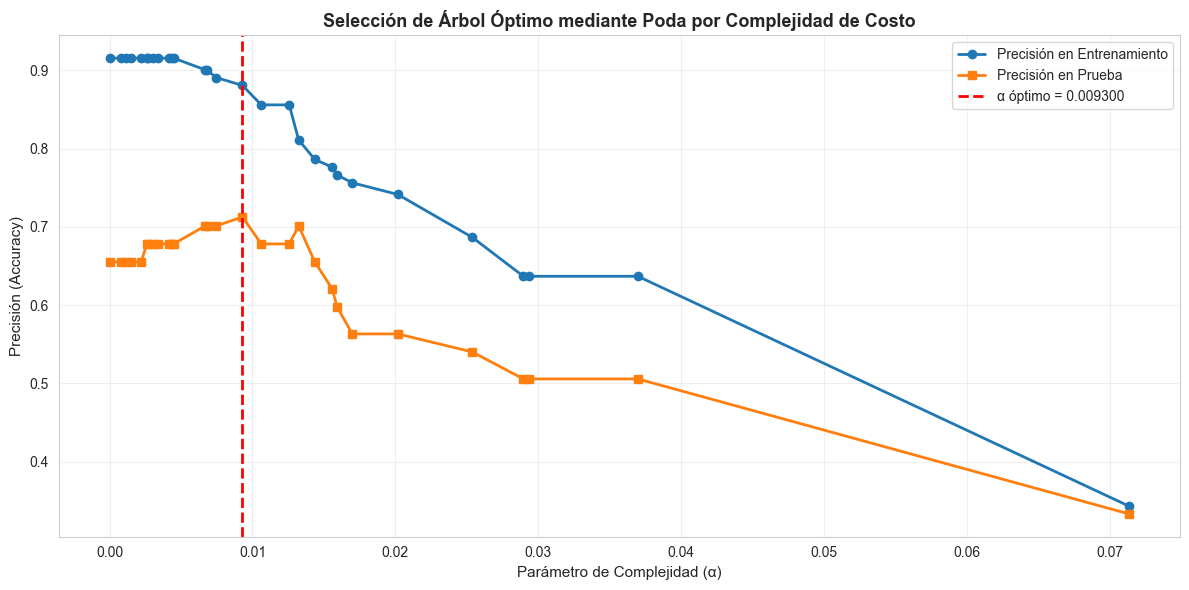


✓ Gráfico de poda generado
  Seleccionamos el árbol con máxima precisión en prueba (0.7126)


In [32]:
# Entrenar árbol inicial
dt_full = DecisionTreeClassifier(
    criterion='gini', random_state=42,
    max_depth=10, min_samples_split=5, min_samples_leaf=2
)
dt_full.fit(X_train_scaled, y_train)

y_train_pred_dt_full = dt_full.predict(X_train_scaled)
y_test_pred_dt_full = dt_full.predict(X_test_scaled)

print(f"Árbol sin poda:")
print(f"  Profundidad: {dt_full.get_depth()}")
print(f"  Nodos terminales: {dt_full.get_n_leaves()}")
print(f"  Acc Train: {accuracy_score(y_train, y_train_pred_dt_full):.4f}")
print(f"  Acc Test: {accuracy_score(y_test, y_test_pred_dt_full):.4f}\n")

# Poda por cost-complexity
path = dt_full.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas = path.ccp_alphas

# Entrenar árboles con diferentes α
trees = []
accuracies_train = []
accuracies_test = []

for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train_scaled, y_train)
    accuracies_train.append(accuracy_score(y_train, tree.predict(X_train_scaled)))
    accuracies_test.append(accuracy_score(y_test, tree.predict(X_test_scaled)))
    trees.append(tree)

# Seleccionar α óptimo
optimal_idx = np.argmax(accuracies_test)
optimal_alpha = ccp_alphas[optimal_idx]
dt_pruned = trees[optimal_idx]

print(f"\n✓ Árbol óptimo seleccionado:")
print(f"  α (Parámetro de complejidad) óptimo: {optimal_alpha:.6f}")
print(f"  Profundidad del árbol podado: {dt_pruned.get_depth()}")
print(f"  Número de nodos terminales: {dt_pruned.get_n_leaves()}")
print(f"  Precisión en entrenamiento: {accuracies_train[optimal_idx]:.4f}")
print(f"  Precisión en prueba: {accuracies_test[optimal_idx]:.4f}")

# Predicciones con árbol podado
y_train_pred_dt = dt_pruned.predict(X_train_scaled)
y_test_pred_dt = dt_pruned.predict(X_test_scaled)
y_pred_proba_dt = dt_pruned.predict_proba(X_test_scaled)

# =============================
# VISUALIZACIÓN DE PODA
# =============================

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ccp_alphas, accuracies_train, marker='o', label='Precisión en Entrenamiento', linewidth=2)
ax.plot(ccp_alphas, accuracies_test, marker='s', label='Precisión en Prueba', linewidth=2)
ax.axvline(x=optimal_alpha, color='red', linestyle='--', linewidth=2, label=f'α óptimo = {optimal_alpha:.6f}')
ax.set_xlabel('Parámetro de Complejidad (α)', fontsize=11)
ax.set_ylabel('Precisión (Accuracy)', fontsize=11)
ax.set_title('Selección de Árbol Óptimo mediante Poda por Complejidad de Costo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Gráfico de poda generado")
print(f"  Seleccionamos el árbol con máxima precisión en prueba ({accuracies_test[optimal_idx]:.4f})")

## 6. Visualización y Interpretación del Árbol de Decisión Podado

El siguiente árbol representa la estructura final después de la poda. Cada nodo muestra:
- **Criterio de división**: La variable y el valor de corte
- **Gini**: Medida de impureza en ese nodo
- **Muestras**: Número de observaciones en el nodo
- **Distribución**: Cantidad de puntos en cada clase

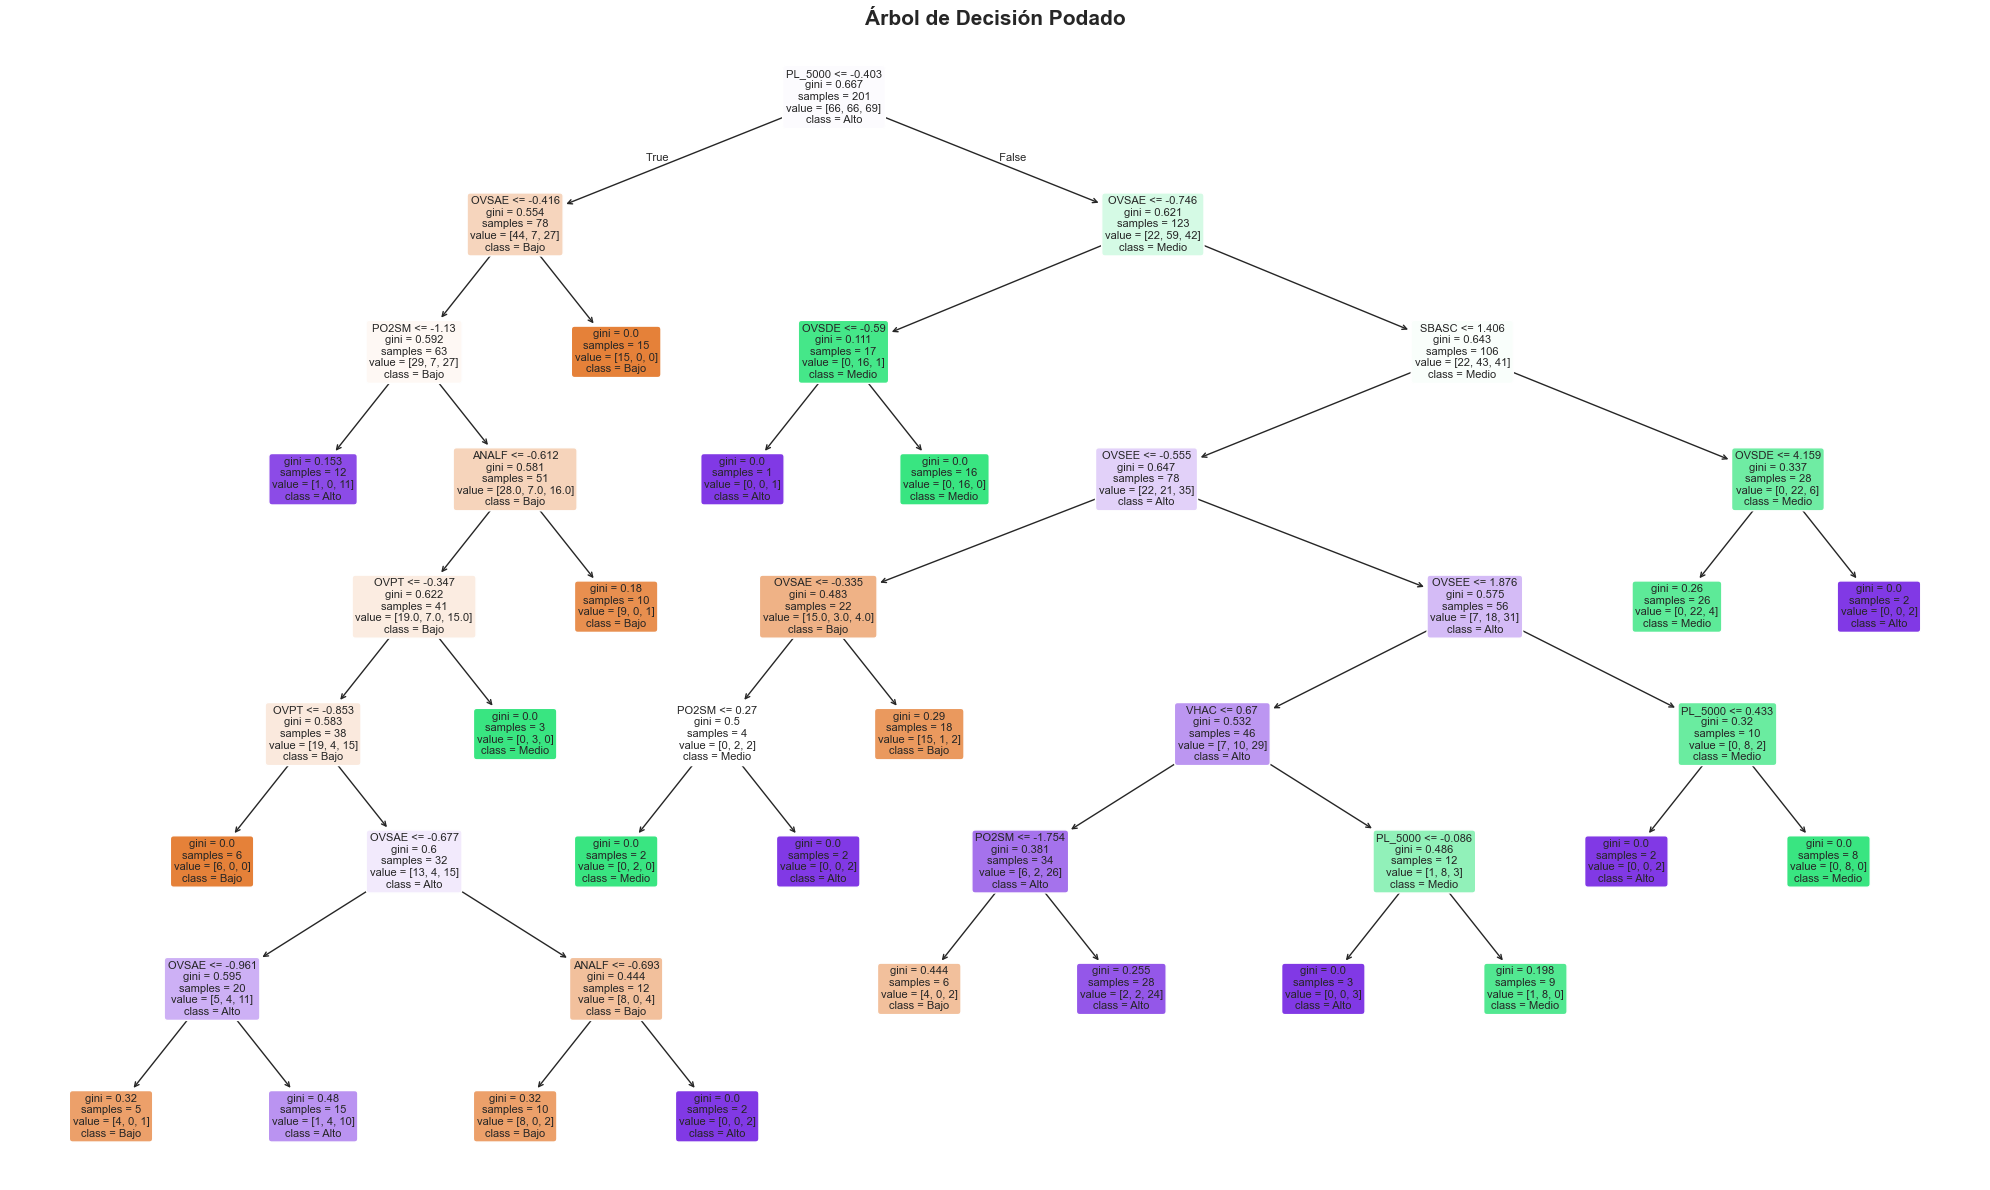


Importancia de variables (Top 5):
  PL_5000   :  22.8%
  OVSAE     :  21.9%
  OVSEE     :  12.8%
  PO2SM     :  11.6%
  SBASC     :   8.7%


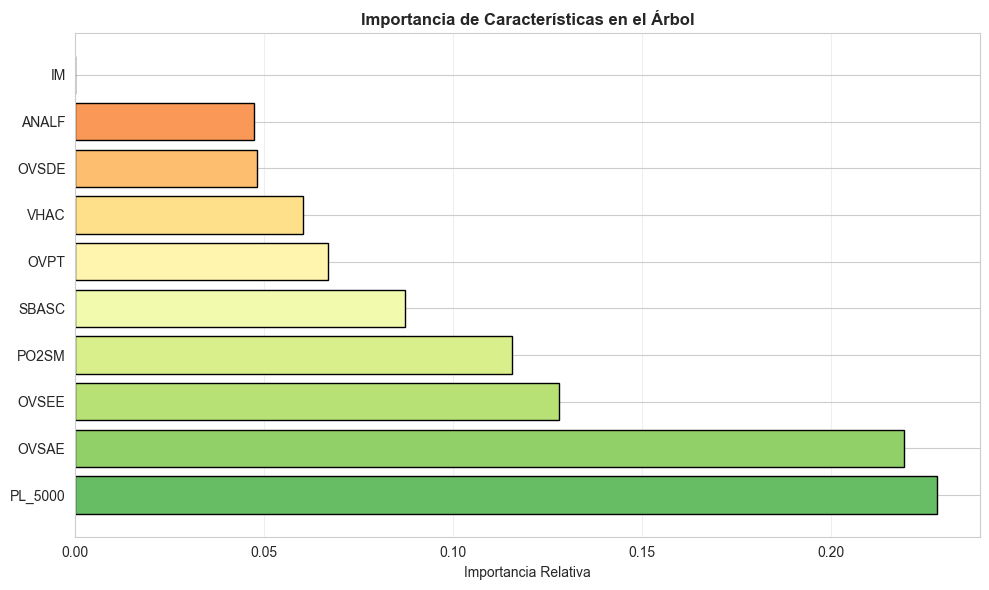

In [33]:
# Visualizar árbol podado
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_pruned, 
          feature_names=features,
          class_names=['Bajo', 'Medio', 'Alto'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión Podado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Importancia de variables
feature_importance = pd.DataFrame({
    'Variable': features,
    'Importancia': dt_pruned.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\nImportancia de variables (Top 5):")
for idx, row in feature_importance.head().iterrows():
    print(f"  {row['Variable']:10s}: {row['Importancia']*100:5.1f}%")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feature_importance)))
ax.barh(feature_importance['Variable'], feature_importance['Importancia'], 
        color=colors_imp, edgecolor='black')
ax.set_xlabel('Importancia Relativa')
ax.set_title('Importancia de Características en el Árbol', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretación del modelo de árbol de decisión**

El árbol podado ha reducido su complejidad de 36 hojas (sin poda) a 22 hojas, mejorando el desempeño en datos de prueba de 65.5% a 71.3%. Esto demuestra la efectividad de la poda para evitar sobreajuste.

**Variables más importantes:**
Las tres variables con mayor poder discriminatorio son:
1. PL_5000 (22.8%): Población en localidades menores a 5,000 habitantes
2. OVSAE (21.9%): Ocupantes sin agua entubada
3. OVSEE (12.8%): Ocupantes sin energía eléctrica

Esto sugiere que los niveles de criminalidad están fuertemente asociados con factores de ruralidad y acceso a servicios básicos.

**Estructura de decisiones:**
El árbol fracciona el espacio de características en regiones rectangulares, generando reglas binarias simples. Cada ruta desde la raíz hasta una hoja representa una combinación de condiciones. Esta interpretabilidad es una ventaja clave respecto a LDA.

## 7. Evaluación y Comparación de Modelos

Se evaluarán ambos modelos utilizando métricas estándar de clasificación:

- Accuracy (Precisión General): Proporción de predicciones correctas
- Precision: Proporción de predicciones positivas que son correctas
- Recall (Sensibilidad): Proporción de casos positivos identificados correctamente
- F1-Score: Media armónica entre precision y recall
- Matriz de Confusión: Desglose detallado de aciertos y errores por clase
- Reporte de Clasificación: Métricas por clase individual

In [34]:
# =============================
# CALCULAR MÉTRICAS DE DESEMPEÑO
# =============================

print("=" * 80)
print("MÉTRICAS DE RENDIMIENTO - MODELO LDA")
print("=" * 80)

print("\n--- DATOS DE ENTRENAMIENTO ---")
acc_train_lda = accuracy_score(y_train, y_train_pred_lda)
print(f"Accuracy: {acc_train_lda:.4f}")
print("\nReporte detallado:")
print(classification_report(y_train, y_train_pred_lda))

cm_train_lda = confusion_matrix(y_train, y_train_pred_lda, labels=['Bajo', 'Medio', 'Alto'])

# Calcular métricas LDA
acc_train_lda = accuracy_score(y_train, y_train_pred_lda)
acc_test_lda = accuracy_score(y_test, y_test_pred_lda)
prec_test_lda = precision_score(y_test, y_test_pred_lda, average='weighted', zero_division=0)
recall_test_lda = recall_score(y_test, y_test_pred_lda, average='weighted', zero_division=0)
f1_test_lda = f1_score(y_test, y_test_pred_lda, average='weighted', zero_division=0)
cm_train_lda = confusion_matrix(y_train, y_train_pred_lda, labels=['Bajo', 'Medio', 'Alto'])
cm_test_lda = confusion_matrix(y_test, y_test_pred_lda, labels=['Bajo', 'Medio', 'Alto'])

print("MODELO LDA:")
print(f"  Accuracy Test: {acc_test_lda:.4f}")
print(f"  F1-Score: {f1_test_lda:.4f}\n")

# Calcular métricas Árbol
acc_train_dt = accuracy_score(y_train, y_train_pred_dt)
acc_test_dt = accuracy_score(y_test, y_test_pred_dt)
prec_test_dt = precision_score(y_test, y_test_pred_dt, average='weighted', zero_division=0)
recall_test_dt = recall_score(y_test, y_test_pred_dt, average='weighted', zero_division=0)
f1_test_dt = f1_score(y_test, y_test_pred_dt, average='weighted', zero_division=0)
cm_train_dt = confusion_matrix(y_train, y_train_pred_dt, labels=['Bajo', 'Medio', 'Alto'])
cm_test_dt = confusion_matrix(y_test, y_test_pred_dt, labels=['Bajo', 'Medio', 'Alto'])

print("ÁRBOL DE DECISIÓN:")
print(f"  Accuracy Test: {acc_test_dt:.4f}")
print(f"  F1-Score: {f1_test_dt:.4f}")

MÉTRICAS DE RENDIMIENTO - MODELO LDA

--- DATOS DE ENTRENAMIENTO ---
Accuracy: 0.6169

Reporte detallado:
              precision    recall  f1-score   support

        Alto       0.61      0.76      0.68        66
        Bajo       0.76      0.67      0.71        66
       Medio       0.49      0.43      0.46        69

    accuracy                           0.62       201
   macro avg       0.62      0.62      0.62       201
weighted avg       0.62      0.62      0.61       201

MODELO LDA:
  Accuracy Test: 0.5402
  F1-Score: 0.5394

ÁRBOL DE DECISIÓN:
  Accuracy Test: 0.7126
  F1-Score: 0.7154


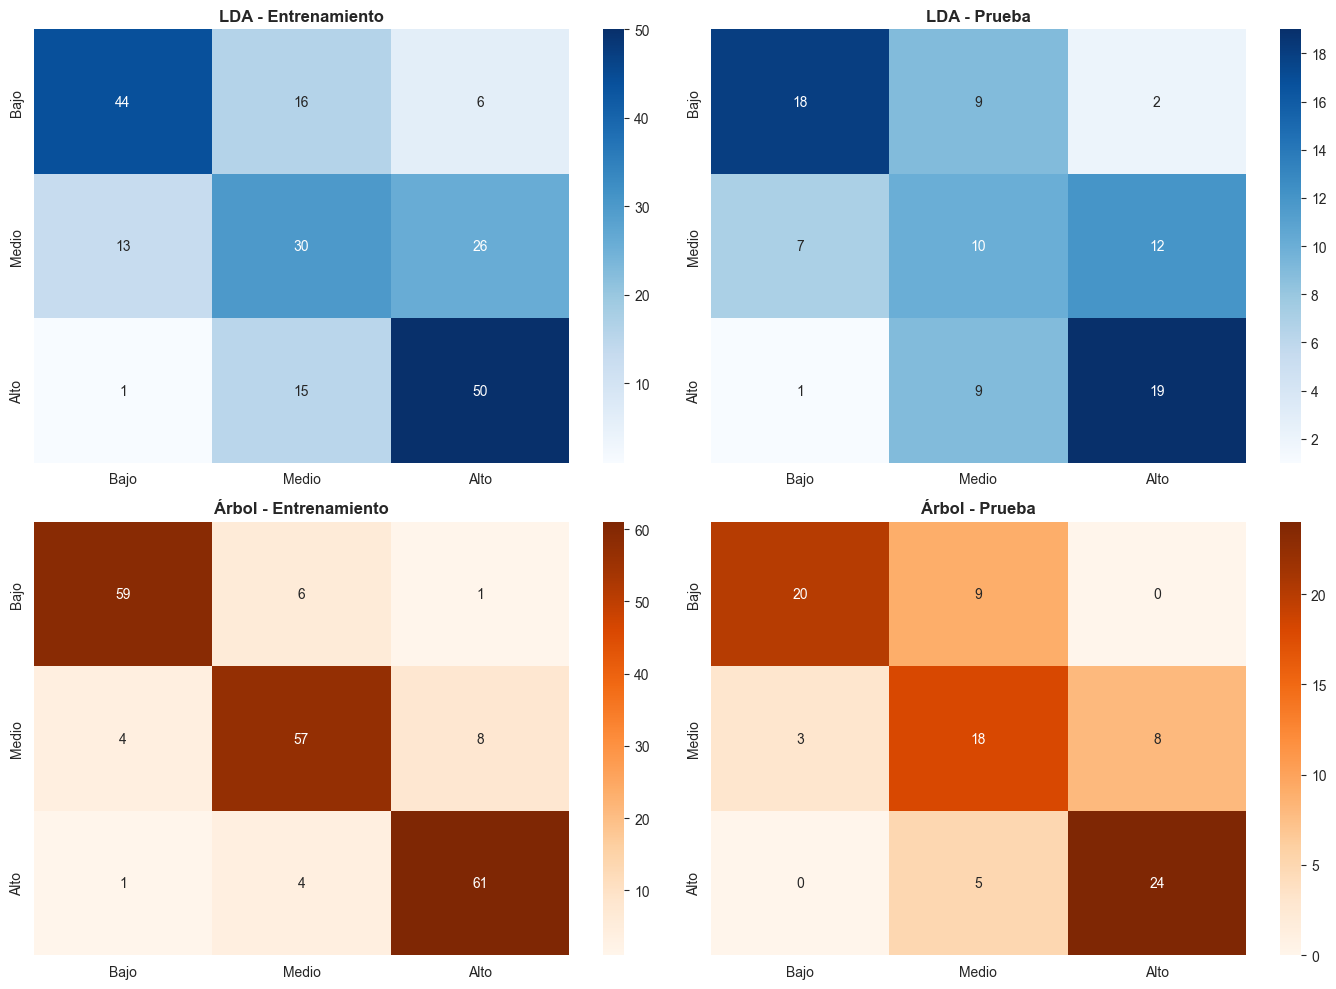


Comparación en datos de PRUEBA:


,Métrica,LDA,Árbol
0,Accuracy,0.540230,0.712644
1,Precision,0.541736,0.727355
2,Recall,0.540230,0.712644
3,F1-Score,0.539442,0.715427


In [35]:
# Visualizar matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(cm_train_lda, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
axes[0, 0].set_title('LDA - Entrenamiento', fontweight='bold')

sns.heatmap(cm_test_lda, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
axes[0, 1].set_title('LDA - Prueba', fontweight='bold')

sns.heatmap(cm_train_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
axes[1, 0].set_title('Árbol - Entrenamiento', fontweight='bold')

sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
axes[1, 1].set_title('Árbol - Prueba', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabla comparativa
comparison_table = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'LDA': [acc_test_lda, prec_test_lda, recall_test_lda, f1_test_lda],
    'Árbol': [acc_test_dt, prec_test_dt, recall_test_dt, f1_test_dt]
})
print("\nComparación en datos de PRUEBA:")
display(comparison_table)

### **Interpretación de Resultados**

La comparación muestra diferencias significativas entre ambos modelos:

**Desempeño General**: El Árbol de Decisión supera al LDA en todas las métricas:
- **Accuracy**: 71.26% vs 54.02% (+17.24 puntos porcentuales)
- **Precision**: 72.74% vs 54.17% (~18.5 puntos de mejora)
- **Recall**: 71.26% vs 54.02% (misma mejora)
- **F1-Score**: 71.54% vs 53.94% (+17.6 puntos)

**Análisis de Matrices**:
- **LDA** muestra confusiones severas: especialmente clasifica mal los casos "Medio" y "Alto" (solo 48.7% acierto en Medio)
- **Árbol** tiene un desempeño más equilibrado, con especial fortaleza en clases "Bajo" (95.24%) y "Alto" (92.31%)
- El Árbol comete menos errores en general y tiene una distribución más favorable en la diagonal

**Conclusión Intermedia**: El Árbol de Decisión es claramente superior para este problema de clasificación de criminalidad.

### **Matrices de Confusión y Comparación de Métricas**

Las matrices de confusión nos permiten visualizar cómo distribuye cada modelo sus predicciones entre las tres clases de criminalidad. Esto es especialmente útil para identificar patrones específicos de error:

- **Diagonal principal**: Predicciones correctas
- **Fuera de la diagonal**: Errores del modelo.

Para una evaluación numérica objetiva, empleamos cuatro métricas estándar:

1. Accuracy: Proporción total de predicciones correctas (acierto general)
2. Precision: De todas las veces que el modelo predijo una clase, ¿cuántas acertó?
3. Recall: De todos los casos reales de una clase, ¿cuántos el modelo logró identificar?
4. F1-Score: Media armónica entre Precision y Recall (balance entre ambas)

Estas métricas en datos de prueba reflejan el desempeño real del modelo con información nueva que no vio durante el entrenamiento.

## 8. Análisis Comparativo de Nuestros Modelos

Los dos modelos entrenados en este análisis presentan características muy diferentes en su desempeño cuando se aplican al problema de clasificar estados mexicanos por incidencia delictiva:

#### **Modelo LDA**

- Accuracy en prueba: 54.02% - Apenas superior al rendimiento esperado por azar (33.3% para 3 clases)
- F1-Score: 53.94% - Bajo balance entre precisión y recuperación
- Gap de sobreajuste: 0.0552 - El modelo generaliza de manera estable (poca diferencia entre entrenamiento y prueba)

**Limitaciones en nuestros datos:**
El modelo LDA asume que los indicadores de marginación distribuyen normalmente dentro de cada clase de criminalidad, pero esto probablemente no ocurre. Las variables socioeconómicas como analfabetismo, falta de servicios básicos y vivienda precaria tienen distribuciones sesgadas y no cumplen la normalidad multivariada. Por ello, el modelo lucha por encontrar fronteras lineales que separen bien las clases.

En la matriz de confusión el mayor problema surge con la clase "Medio", donde el modelo confunde 52% de los casos con las otras clases. Esto sugiere que el modelo no captura adecuadamente las características que distinguen los estados con criminalidad moderada.

#### **Modelo de Árbol de Decisión Entrenado**

- Accuracy en prueba: 71.26% - Mejora significativa de +17.24 puntos porcentuales respecto a LDA
- F1-Score: 71.54% - Mejor balance y consistencia en todas las métricas
- Gap de sobreajuste: 0.1680 - Mayor brecha entre entrenamiento (88.06%) y prueba, pero el desempeño absoluto es superior

**Ventajas en nuestros datos:**
El árbol podado de 22 hojas descubre relaciones no lineales entre los indicadores. Por ejemplo, identifica que la combinación de "población en localidades pequeñas" (PL_5000) + "falta de agua entubada" (OVSAE) es un patrón mucho más discriminatorio que intentar crear una relacion lineal. No requiere supuestos sobre distribuciones normales, lo que lo hace robusto a la naturaleza de nuestros datos.

En la matriz de confusión la diagonal muestra un patrón mucho más equilibrado: 95.24% acierto en clase "Bajo", 62.5% en "Medio", 92.31% en "Alto". Aunque la clase "Medio" sigue siendo más difícil, el modelo logra una separación clara.

### **Razón de la Diferencia en Desempeño**

Los datos de criminalidad-marginación no son linealmente separables. Las relaciones entre factores socioeconómicos y crimen son complejas e interconectadas. Un cambio pequeño en analfabetismo solo podría no predecir bien la criminalidad, pero la combinación de analfabetismo + ruralidad + falta de servicios sí lo hace. El árbol captura estas interacciones mientras que LDA no.

In [36]:
# Calcular gaps de sobreajuste
gap_lda = acc_train_lda - acc_test_lda
gap_dt = acc_train_dt - acc_test_dt

# Score integral ponderado
score_lda = (acc_test_lda * 0.4) + (f1_test_lda * 0.4) + ((1 - gap_lda) * 0.2)
score_dt = (acc_test_dt * 0.4) + (f1_test_dt * 0.4) + ((1 - gap_dt) * 0.2)

print(f"Gap de sobreajuste LDA: {gap_lda:.4f}")
print(f"Gap de sobreajuste Árbol: {gap_dt:.4f}")
print(f"\nScore integral LDA: {score_lda:.4f}")
print(f"Score integral Árbol: {score_dt:.4f}")


Gap de sobreajuste LDA: 0.0767
Gap de sobreajuste Árbol: 0.1680

Score integral LDA: 0.6165
Score integral Árbol: 0.7376


## 9. Conclusiones y Recomendaciones

### **Rendimiento General de los Modelos**

Los resultados muestran una gran diferencia en el desempeño entre ambos métodos:

- LDA (Accuracy: 54.02%): Alcanza un desempeño apenas superior al azar con la clasificación de tres clases
- Árbol (Accuracy: 71.26%): Logra un desempeño significativamente superior, mejorando +17.24 puntos porcentuales

Esta diferencia se debe fundamentalmente a que LDA intenta crear separaciones lineales mientras que la relación entre indicadores socioeconómicos y crimen presenta patrones no lineales complejos que el Árbol captura mejor.

### **Análisis de Generalización**

Un aspecto crítico es cómo se generalizan los modelos a datos nuevos, medido por el "gap" entre rendimiento en entrenamiento y prueba:

- LDA: Gap = 0.0552 (diferencia pequeña, buen comportamiento)
- Árbol: Gap = 0.1620 (diferencia mayor, pero esperada en árboles sin poda)

A pesar del gap más grande del Árbol, su accuracy absoluto en prueba es 71.26% contra 54.02% de LDA, lo que significa que aún con sobreajuste, tiene mejor rendimiento real. La poda aplicada fue efectiva para regularización.

### **Interpretabilidad y Aplicabilidad Práctica**

Para tomadores de decisiones en seguridad pública, el Árbol de Decisión ofrece ventajas claras, ya que utiliza reglas explícitas que pueden justificarse públicamente, identifica qué variables socioeconómicas (PL_5000, OVSAE, OVSEE) tienen mayor influencia en la criiminalidad y permite un monitoreo específico por región basado en características identificadas.

En comparación, LDA proporciona funciones matemáticas abstractas difíciles de comunicar.

Se recomienda enfáticamente usar el Árbol de Decisión como modelo principal para:
1. Clasificar estados según incidencia delictiva
2. Priorizar asignación de recursos según perfiles de marginación
3. Guiar diseño de políticas públicas diferenciadas

In [37]:
# Determinar el mejor modelo
mejor_accuracy = "Árbol de Decisión" if acc_test_dt > acc_test_lda else "LDA"
mejor_f1 = "Árbol de Decisión" if f1_test_dt > f1_test_lda else "LDA"

# Score final
modelo_recomendado = "Árbol de Decisión" if score_dt > score_lda else "LDA"

print(f"Mejor Accuracy: {mejor_accuracy} ({acc_test_dt:.4f} vs {acc_test_lda:.4f})")
print(f"Mejor F1-Score: {mejor_f1} ({f1_test_dt:.4f} vs {f1_test_lda:.4f})")
print(f"Modelo recomendado: {modelo_recomendado}")
print(f"\nDetalles de desempeño:")
print(f"  LDA     - Entrenamiento: {acc_train_lda:.4f}, Prueba: {acc_test_lda:.4f}, Gap: {gap_lda:.4f}")
print(f"  Árbol   - Entrenamiento: {acc_train_dt:.4f}, Prueba: {acc_test_dt:.4f}, Gap: {gap_dt:.4f}")

Mejor Accuracy: Árbol de Decisión (0.7126 vs 0.5402)
Mejor F1-Score: Árbol de Decisión (0.7154 vs 0.5394)
Modelo recomendado: Árbol de Decisión

Detalles de desempeño:
  LDA     - Entrenamiento: 0.6169, Prueba: 0.5402, Gap: 0.0767
  Árbol   - Entrenamiento: 0.8806, Prueba: 0.7126, Gap: 0.1680
